In [1]:
import os
import zipfile

zip_path = "model_dataset.zip"

extract_dir = os.getcwd()
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f" Dataset extracted to: {extract_dir}")

 Dataset extracted to: /content


In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import cv2
from PIL import Image
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.efficientnet import preprocess_input

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

In [4]:
import os
import shutil

# Paths (CHANGE ONLY IF NEEDED)
images_path = "MedLeaves/MedLeaves/train/images"
labels_path = "MedLeaves/MedLeaves/train/labels"
output_path = "converted_dataset/train"

os.makedirs(output_path, exist_ok=True)

for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):

        label_path = os.path.join(labels_path, label_file)

        with open(label_path, 'r') as f:
            lines = f.readlines()

        # Skip empty labels
        if len(lines) == 0:
            continue

        # Get class id (first object)
        class_id = lines[0].split()[0]

        # Create class folder
        class_folder = os.path.join(output_path, class_id)
        os.makedirs(class_folder, exist_ok=True)

        # Get image name
        image_name = label_file.replace(".txt", ".jpg")
        image_path = os.path.join(images_path, image_name)

        if os.path.exists(image_path):
            shutil.copy(image_path, class_folder)

print("Step 1 Completed ✅ (YOLO → Classification)")

Step 1 Completed ✅ (YOLO → Classification)


In [5]:
print(os.listdir("converted_dataset/train"))

['18', '20', '16', '9', '29', '12', '4', '5', '10', '0', '8', '28', '24', '14', '2', '21', '27', '6', '25', '11', '3', '26', '19', '1', '22', '17', '7', '15', '23', '13']


In [6]:
print(len(os.listdir("converted_dataset/train")))

30


In [7]:
for cls in os.listdir("converted_dataset/train"):
    path = os.path.join("converted_dataset/train", cls)
    print(cls, "→", len(os.listdir(path)))

18 → 409
20 → 405
16 → 411
9 → 410
29 → 409
12 → 414
4 → 405
5 → 405
10 → 416
0 → 415
8 → 409
28 → 411
24 → 411
14 → 412
2 → 414
21 → 415
27 → 406
6 → 416
25 → 407
11 → 412
3 → 411
26 → 413
19 → 413
1 → 408
22 → 409
17 → 411
7 → 403
15 → 408
23 → 414
13 → 410


In [8]:
import os
import shutil

images_path = "MedLeaves/MedLeaves/valid/images"
labels_path = "MedLeaves/MedLeaves/valid/labels"
output_path = "converted_dataset/valid"

os.makedirs(output_path, exist_ok=True)

for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):

        label_path = os.path.join(labels_path, label_file)

        with open(label_path, 'r') as f:
            lines = f.readlines()

        if len(lines) == 0:
            continue

        class_id = lines[0].split()[0]

        class_folder = os.path.join(output_path, class_id)
        os.makedirs(class_folder, exist_ok=True)

        image_name = label_file.replace(".txt", ".jpg")
        image_path = os.path.join(images_path, image_name)

        if os.path.exists(image_path):
            shutil.copy(image_path, class_folder)

print("VALID conversion done ✅")

VALID conversion done ✅


In [9]:
images_path = "MedLeaves/MedLeaves/test/images"
labels_path = "MedLeaves/MedLeaves/test/labels"
output_path = "converted_dataset/test"

os.makedirs(output_path, exist_ok=True)

for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):

        label_path = os.path.join(labels_path, label_file)

        with open(label_path, 'r') as f:
            lines = f.readlines()

        if len(lines) == 0:
            continue

        class_id = lines[0].split()[0]

        class_folder = os.path.join(output_path, class_id)
        os.makedirs(class_folder, exist_ok=True)

        image_name = label_file.replace(".txt", ".jpg")
        image_path = os.path.join(images_path, image_name)

        if os.path.exists(image_path):
            shutil.copy(image_path, class_folder)

print("TEST conversion done ✅")

TEST conversion done ✅


In [10]:
print("Train classes:", os.listdir("converted_dataset/train")[:5])
print("Valid classes:", os.listdir("converted_dataset/valid")[:5])
print("Test classes:", os.listdir("converted_dataset/test")[:5])

Train classes: ['18', '20', '16', '9', '29']
Valid classes: ['18', '20', '16', '9', '29']
Test classes: ['18', '20', '16', '9', '29']


In [11]:
import os
print(os.listdir('/content'))

['.config', 'MedLeaves', 'converted_dataset', 'CroppedMedLeaves', 'model_dataset.zip', 'sample_data']


In [18]:
import os
import shutil

dataset1 = "converted_dataset/train"
dataset2 = "CroppedMedLeaves/CroppedMedLeaves/train"
combined_path = "final_dataset/train"

os.makedirs(combined_path, exist_ok=True)

for class_name in os.listdir(dataset1):
    os.makedirs(os.path.join(combined_path, class_name), exist_ok=True)

    # Copy converted dataset
    for file in os.listdir(os.path.join(dataset1, class_name)):
        shutil.copy(
            os.path.join(dataset1, class_name, file),
            os.path.join(combined_path, class_name)
        )

    # Copy cropped dataset
    if class_name in os.listdir(dataset2):
        for file in os.listdir(os.path.join(dataset2, class_name)):
            shutil.copy(
                os.path.join(dataset2, class_name, file),
                os.path.join(combined_path, class_name)
            )

print("✅ final_dataset created successfully")

✅ final_dataset created successfully


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
base_path = '/content/final_dataset/train'
print("Folders inside base_path:", os.listdir(base_path))

Folders inside base_path: ['18', '20', '16', '9', '29', '12', '4', '5', '10', '0', '8', '28', '24', '14', '2', '21', '27', '6', '25', '11', '3', '26', '19', '1', '22', '17', '7', '15', '23', '13']


In [21]:
if not os.path.exists(base_path):
    raise FileNotFoundError(f"Data directory not found at: {base_path}")

In [ ]:
# #Class Distribution(Full)
# labels = os.listdir(base_path)
# label_counts = {label: len(os.listdir(os.path.join(base_path, label))) for label in labels}

# # Show results
# print("Total Labels (Classes):", len(labels))
# print("Labels and their image counts:", label_counts)

# # Plot bar chart
# plt.figure(figsize=(10,6))
# plt.bar(label_counts.keys(), label_counts.values(), color='skyblue')
# plt.xticks(rotation=45, ha="right")
# plt.xlabel("Labels")
# plt.ylabel("Number of Images")
# plt.title("Image Count per Label")
# plt.show()

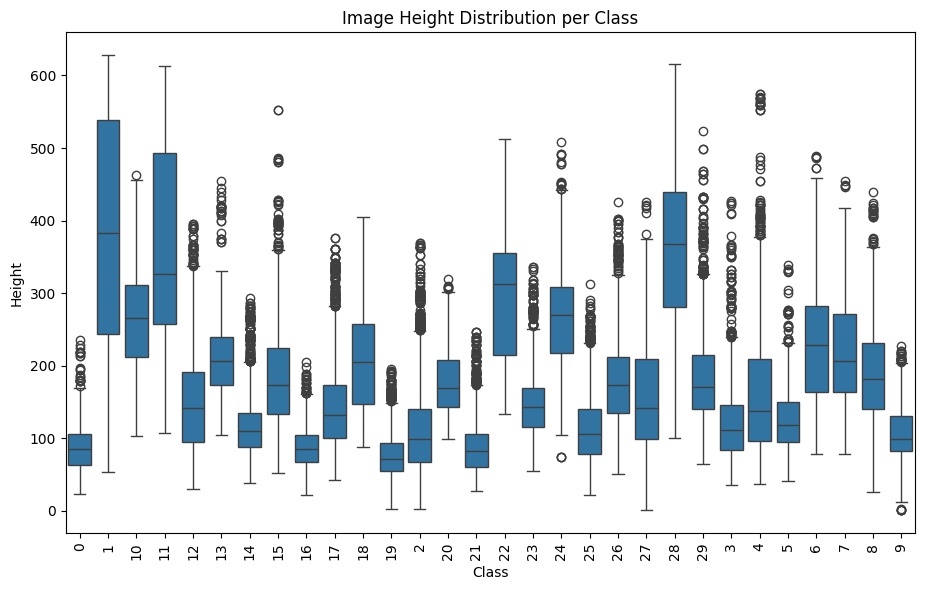

In [ ]:
dataset_path = "/content/CroppedMedLeaves/CroppedMedLeaves/train"
classes = sorted(os.listdir(dataset_path))  # sort classes alphabetically

image_data = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path)
                width, height = img.size
                image_data.append([cls, width, height])
            except:
                pass

df = pd.DataFrame(image_data, columns=["Class", "Width", "Height"])

# ---------------------------
# 2. Boxplot for Width & Height
# ---------------------------
plt.figure(figsize=(18,6))  # make bigger figure

plt.subplot(1,2,2)
sns.boxplot(data=df, x="Class", y="Height", order=classes)  # force all classes
plt.xticks(rotation=90)
plt.title("Image Height Distribution per Class")

plt.tight_layout()
plt.show()

In [22]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = datagen.flow_from_directory(
    "/content/final_dataset/train",
    target_size=(240,240),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    "/content/CroppedMedLeaves/CroppedMedLeaves/valid",
    target_size=(240,240),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_data = datagen.flow_from_directory(
    "/content/CroppedMedLeaves/CroppedMedLeaves/test",
    target_size=(240,240),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 66766 images belonging to 30 classes.
Found 4214 images belonging to 30 classes.
Found 4086 images belonging to 30 classes.


In [23]:
# Get the number of images from the .samples attribute of each generator
num_train_images = train_data.samples
num_val_images = val_data.samples
total_images = num_train_images + num_val_images

# Print the results in a formatted way
print(f"Total images found and split: {total_images}")
print("---------------------------------------------")
print(f"Number of images in the training set: {num_train_images}")
print(f"Number of images in the validation set: {num_val_images}")

Total images found and split: 70980
---------------------------------------------
Number of images in the training set: 66766
Number of images in the validation set: 4214


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from collections import Counter



# # 1. Get the class labels for every image in the training set
# train_labels = train_data.classes

# # 2. Get the mapping from class index to class name
# # The generator stores it as {'class_name': index}, we need to invert it
# class_names = {v: k for k, v in train_data.class_indices.items()}

# # 3. Count the occurrences of each class index
# train_class_counts = Counter(train_labels)

# # 4. Prepare data for plotting (class names and their counts)
# class_names_list = [class_names[i] for i in sorted(train_class_counts.keys())]
# class_counts_list = [train_class_counts[i] for i in sorted(train_class_counts.keys())]

# # 5. Create the bar chart
# plt.figure(figsize=(12, 14))
# sns.barplot(x=class_counts_list, y=class_names_list, orient='h')

# plt.title('Number of Training Images per Class', fontsize=16)
# plt.xlabel('Number of Images', fontsize=12)
# plt.ylabel('Class', fontsize=12)
# plt.tight_layout()
# plt.show()
print(train_data.class_indices)

{'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '4': 24, '5': 25, '6': 26, '7': 27, '8': 28, '9': 29}


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from collections import Counter

# # --- This part assumes your 'val_data' generator is already created ---

# # 1. Get the class labels for every image in the validation set
# val_labels = val_data.classes

# # 2. Get the mapping from class index to class name
# # (This will be the same as the training generator's)
# class_names = {v: k for k, v in val_data.class_indices.items()}

# # 3. Count the occurrences of each class index
# val_class_counts = Counter(val_labels)

# # 4. Prepare data for plotting (class names and their counts)
# class_names_list = [class_names[i] for i in sorted(val_class_counts.keys())]
# class_counts_list = [val_class_counts[i] for i in sorted(val_class_counts.keys())]

# # 5. Create the bar chart
# plt.figure(figsize=(12, 14))
# sns.barplot(x=class_counts_list, y=class_names_list, orient='h')

# plt.title('Number of Validation Images per Class', fontsize=16)
# plt.xlabel('Number of Images', fontsize=12)
# plt.ylabel('Class', fontsize=12)
# plt.tight_layout()
# plt.show()

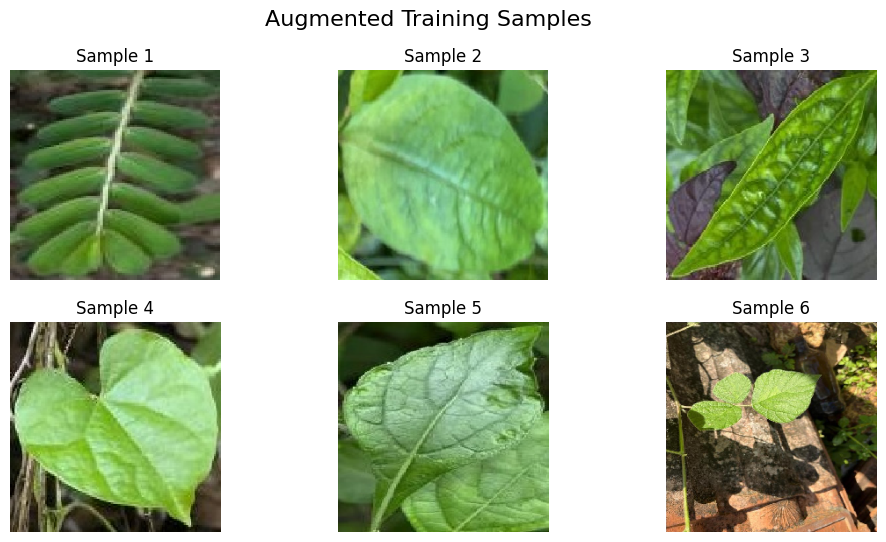

In [24]:
x_batch, y_batch = next(train_data)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

for i in range(6):
    plt.subplot(2, 3, i+1)

    img = x_batch[i]

    # Convert back to displayable range
    img = img.copy()
    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Sample {i+1}")

plt.suptitle("Augmented Training Samples", fontsize=16)
plt.show()

In [25]:
print(" Classes found:", train_data.class_indices)
print(" Training samples:", train_data.samples)
print(" Validation samples:", val_data.samples)

 Classes found: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '4': 24, '5': 25, '6': 26, '7': 27, '8': 28, '9': 29}
 Training samples: 66766
 Validation samples: 4214


In [26]:
# Get class labels (dictionary)
class_labels = train_data.class_indices
labels = list(class_labels.keys())

# Training distribution
train_counts = dict(zip(labels, np.bincount(train_data.classes)))

# Validation distribution
val_counts = dict(zip(labels, np.bincount(val_data.classes)))
train_counts = {label: int(count) for label, count in zip(labels, np.bincount(train_data.classes))}
val_counts   = {label: int(count) for label, count in zip(labels, np.bincount(val_data.classes))}

print("Train Class Distribution:", train_counts)
print("Validation Class Distribution:", val_counts)


Train Class Distribution: {'0': 2737, '1': 906, '10': 1004, '11': 1024, '12': 2815, '13': 1220, '14': 3162, '15': 2013, '16': 2648, '17': 3073, '18': 1091, '19': 5445, '2': 6244, '20': 1287, '21': 3307, '22': 949, '23': 1689, '24': 1138, '25': 5185, '26': 1668, '27': 1403, '28': 1029, '29': 1552, '3': 1995, '4': 3487, '5': 1680, '6': 1185, '7': 973, '8': 1972, '9': 2885}
Validation Class Distribution: {'0': 158, '1': 37, '10': 51, '11': 43, '12': 204, '13': 64, '14': 221, '15': 118, '16': 152, '17': 243, '18': 41, '19': 266, '2': 515, '20': 65, '21': 193, '22': 35, '23': 92, '24': 44, '25': 381, '26': 110, '27': 61, '28': 45, '29': 104, '3': 178, '4': 245, '5': 103, '6': 60, '7': 47, '8': 155, '9': 183}


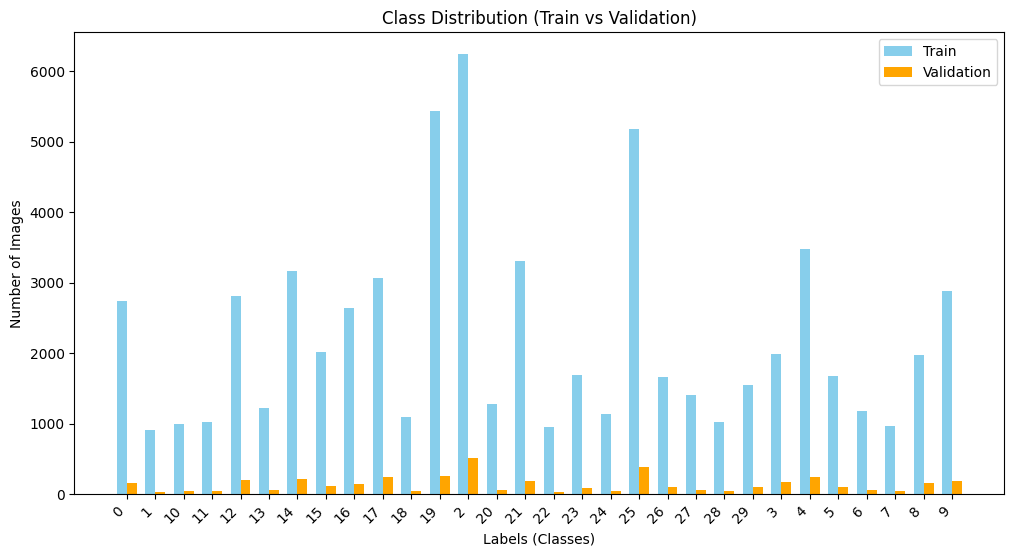

In [27]:
#1.Class distribution (train vs validation)
labels = list(train_counts.keys())
train_values = list(train_counts.values())
val_values = [val_counts.get(label, 0) for label in labels]  # match same labels

x = np.arange(len(labels))  # label positions
width = 0.35  # bar width

plt.figure(figsize=(12,6))
plt.bar(x - width/2, train_values, width, label='Train', color='skyblue')
plt.bar(x + width/2, val_values, width, label='Validation', color='orange')

plt.xticks(x, labels, rotation=45, ha="right")
plt.xlabel("Labels (Classes)")
plt.ylabel("Number of Images")
plt.title("Class Distribution (Train vs Validation)")
plt.legend()
plt.show()

In [28]:
# from collections import Counter

# def imbalance_ratio(counts):
#     max_count = max(counts.values())
#     min_count = min(counts.values())
#     return min_count / max_count

# print("Train imbalance ratio:", imbalance_ratio(train_counts))
# print("Validation imbalance ratio:", imbalance_ratio(val_counts))
from collections import Counter

# Get class labels from generator
train_labels = train_data.classes
val_labels = val_data.classes

# Count occurrences
train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

print("Train class distribution:", train_counts)
print("Validation class distribution:", val_counts)
def imbalance_ratio(counts):
    max_count = max(counts.values())
    min_count = min(counts.values())
    return min_count / max_count

print("Train imbalance ratio:", imbalance_ratio(train_counts))
print("Validation imbalance ratio:", imbalance_ratio(val_counts))

Train class distribution: Counter({np.int32(12): 6244, np.int32(11): 5445, np.int32(18): 5185, np.int32(24): 3487, np.int32(14): 3307, np.int32(6): 3162, np.int32(9): 3073, np.int32(29): 2885, np.int32(4): 2815, np.int32(0): 2737, np.int32(8): 2648, np.int32(7): 2013, np.int32(23): 1995, np.int32(28): 1972, np.int32(16): 1689, np.int32(25): 1680, np.int32(19): 1668, np.int32(22): 1552, np.int32(20): 1403, np.int32(13): 1287, np.int32(5): 1220, np.int32(26): 1185, np.int32(17): 1138, np.int32(10): 1091, np.int32(21): 1029, np.int32(3): 1024, np.int32(2): 1004, np.int32(27): 973, np.int32(15): 949, np.int32(1): 906})
Validation class distribution: Counter({np.int32(12): 515, np.int32(18): 381, np.int32(11): 266, np.int32(24): 245, np.int32(9): 243, np.int32(6): 221, np.int32(4): 204, np.int32(14): 193, np.int32(29): 183, np.int32(23): 178, np.int32(0): 158, np.int32(28): 155, np.int32(8): 152, np.int32(7): 118, np.int32(19): 110, np.int32(22): 104, np.int32(25): 103, np.int32(16): 92, np

In [33]:
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Load pretrained EfficientNet
base_model = EfficientNetB1(
    input_shape=(240, 240, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

In [34]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels
classes = train_data.classes

# Compute weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

# Convert to dictionary
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.8131287297527706), 1: np.float64(2.456438557763061), 2: np.float64(2.216666666666667), 3: np.float64(2.1733723958333333), 4: np.float64(0.7905979869745412), 5: np.float64(1.824207650273224), 6: np.float64(0.7038372338182585), 7: np.float64(1.1055803941049842), 8: np.float64(0.8404582074521652), 9: np.float64(0.7242217160212604), 10: np.float64(2.0399022303696914), 11: np.float64(0.4087297214569942), 12: np.float64(0.3564275037369208), 13: np.float64(1.7292411292411292), 14: np.float64(0.6729765144642678), 15: np.float64(2.3451352300667367), 16: np.float64(1.3176633116242353), 17: np.float64(1.9556531927357939), 18: np.float64(0.42922532947605274), 19: np.float64(1.3342525979216626), 20: np.float64(1.5862675219767166), 21: np.float64(2.16281179138322), 22: np.float64(1.4339776632302406), 23: np.float64(1.1155555555555556), 24: np.float64(0.6382372622120256), 25: np.float64(1.3247222222222221), 26: np.float64(1.878087201125176), 27: np.float64(2.2872901678

In [35]:
num_classes = len(train_data.class_indices)

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb1 (Functional)     │ (None, 8, 8, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,917,029 (26.39 MB)

 Trainable params: 338,718 (1.29 MB)

 Non-trainable params: 6,578,311 (25.09 MB)

In [36]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
initial_history = model.fit(train_data, validation_data=val_data, epochs=5)

Epoch 1/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 282s 112ms/step - accuracy: 0.5810 - loss: 1.5674 - val_accuracy: 0.9286 - val_loss: 0.3017
Epoch 2/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 164s 79ms/step - accuracy: 0.8116 - loss: 0.6391 - val_accuracy: 0.9589 - val_loss: 0.1649
Epoch 3/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 160s 77ms/step - accuracy: 0.8649 - loss: 0.4508 - val_accuracy: 0.9732 - val_loss: 0.1138
Epoch 4/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 160s 77ms/step - accuracy: 0.8886 - loss: 0.3678 - val_accuracy: 0.9772 - val_loss: 0.0920
Epoch 5/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 169s 81ms/step - accuracy: 0.9025 - loss: 0.3231 - val_accuracy: 0.9820 - val_loss: 0.0761


In [37]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [38]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
steps_per_epoch = train_data.samples // train_data.batch_size
validation_steps = val_data.samples // val_data.batch_size

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights,   # 🔥 ADD THIS LINE
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 251s 100ms/step - accuracy: 0.8788 - loss: 0.3823 - val_accuracy: 0.9827 - val_loss: 0.0678 - learning_rate: 1.0000e-05
Epoch 2/15
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 175s 84ms/step - accuracy: 0.9088 - loss: 0.2756 - val_accuracy: 0.9869 - val_loss: 0.0543 - learning_rate: 1.0000e-05
Epoch 3/15
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 172s 83ms/step - accuracy: 0.9240 - loss: 0.2216 - val_accuracy: 0.9888 - val_loss: 0.0462 - learning_rate: 1.0000e-05
Epoch 4/15
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 171s 82ms/step - accuracy: 0.9361 - loss: 0.1865 - val_accuracy: 0.9910 - val_loss: 0.0407 - learning_rate: 1.0000e-05
Epoch 5/15
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 174s 83ms/step - accuracy: 0.9433 - loss: 0.1600 - val_accuracy: 0.9929 - val_loss: 0.0349 - learning_rate: 1.0000e-05
Epoch 6/15
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 172s 83ms/step - accuracy: 0.9501 - loss: 0.1422 - val_accuracy: 0.9931 - val_loss: 0.0318 - learning_rate: 1.0000e-05
Epoch 7/15
2087/2087 ━━━━━━━━━━━━

In [39]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9939 - loss: 0.0220
Test Accuracy: 0.9938815236091614


In [40]:
model.save("herb_model.keras")
print("Model saved successfully ✅")

Model saved successfully ✅


In [41]:
from google.colab import files
files.download("herb_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
from tensorflow.keras.models import load_model

model = load_model("herb_model.keras")
print("Model loaded successfully ✅")

Model loaded successfully ✅


In [43]:
class_labels = list(train_data.class_indices.keys())
print("Classes:", class_labels)

Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '4', '5', '6', '7', '8', '9']


In [82]:
from google.colab import files

uploaded = files.upload()

Saving testing_images.zip to testing_images (1).zip


In [83]:
# Get class indices
class_indices = train_data.class_indices

# Reverse mapping (index → folder name)
index_to_folder = {v: k for k, v in class_indices.items()}

# Folder → actual herb name
folder_to_name = {
'0': 'Aerva lanata',
'1': 'Aloe vera',
'2': 'Andrographis paniculata',
'3': 'Bacopa monnieri',
'4': 'Calotropis gigantea',
'5': 'Centella asiatica',
'6': 'Chromolaena odorata',
'7': 'Cissus quadrangularis',
'8': 'Clerodendrum infortunatum',
'9': 'Clitoria ternatea',
'10': 'Coccinia grandis',
'11': 'Curcuma longa',
'12': 'Datura metal linn',
'13': 'Desmodium gangeticum',
'14': 'Hemigraphis colorata',
'15': 'Kaempferia galanga linn',
'16': 'Mentha spicata',
'17': 'Ocimum gratissimum',
'18': 'Ocimum tenuiflorum',
'19': 'Oxalis corniculata',
'20': 'Peperomia pellucida',
'21': 'Phyllanthus niruri',
'22': 'Piper betle',
'23': 'Piper longum',
'24': 'Piper nigrum',
'25': 'Plectranthus barbatus',
'26': 'Plumbago indica',
'27': 'Pseudarthria viscida',
'28': 'Ricinus communis linn',
'29': 'Tinospora cordifolia'
}

In [74]:
herb_info = {
"Aerva lanata": "A medicinal herb used in Ayurveda, commonly found in India. Used for kidney stones and urinary infections. It helps in detoxification and improving kidney function.",

"Aloe vera": "A succulent medicinal plant used in skincare and digestion. Commonly used worldwide. It helps in healing burns, improving skin health, and aiding digestion.",

"Andrographis paniculata": "A bitter herb known as 'King of Bitters'. Used in traditional medicine for infections. It boosts immunity and treats fever and respiratory problems.",

"Bacopa monnieri": "A brain tonic herb used in Ayurveda. Used for memory enhancement and stress relief. It improves cognitive function and reduces anxiety.",

"Calotropis gigantea": "A shrub used in traditional medicine. Found in tropical regions. Used for skin diseases and pain relief due to its anti-inflammatory properties.",

"Centella asiatica": "Also called Gotu Kola. Used for brain health and wound healing. Improves memory, circulation, and skin repair.",

"Chromolaena odorata": "A medicinal weed used in wound healing. Common in tropical regions. Helps stop bleeding and speeds up tissue repair.",

"Cissus quadrangularis": "A medicinal vine used for bone healing. Used in fracture treatment. Helps in bone regeneration and strengthening.",

"Clerodendrum infortunatum": "A medicinal shrub used in traditional treatments. Used for skin diseases and fever. Has anti-inflammatory and antimicrobial properties.",

"Clitoria ternatea": "Also known as butterfly pea. Used in herbal tea and brain health. Improves memory and acts as an antioxidant.",

"Coccinia grandis": "A climbing herb used in diabetes treatment. Helps control blood sugar levels and improves metabolism.",

"Curcuma longa": "Turmeric plant widely used in cooking and medicine. Known for anti-inflammatory and antioxidant properties.",

"Datura metal linn": "A toxic medicinal plant used carefully in traditional medicine. Used for pain relief and respiratory issues.",

"Desmodium gangeticum": "A medicinal herb used in Ayurveda. Used for fever, inflammation, and improving immunity.",

"Hemigraphis colorata": "Used in traditional medicine for wound healing. Helps in blood clotting and skin repair.",

"Kaempferia galanga linn": "Aromatic medicinal plant. Used in digestion and respiratory treatments. Helps reduce inflammation.",

"Mentha spicata": "Mint plant used in food and medicine. Helps in digestion and provides cooling effect.",

"Ocimum gratissimum": "Medicinal basil used for infections. Has antibacterial and antifungal properties.",

"Ocimum tenuiflorum": "Holy basil (Tulsi). Used for immunity and respiratory health. Reduces stress and boosts immunity.",

"Oxalis corniculata": "A small herb used in traditional medicine. Helps in digestion and treating wounds.",

"Peperomia pellucida": "A medicinal herb used for joint pain and inflammation. Helps in reducing swelling.",

"Phyllanthus niruri": "Known as stonebreaker plant. Used for kidney stones and liver health.",

"Piper betle": "Betel leaf used in traditional practices. Helps digestion and has antimicrobial properties.",

"Piper longum": "Long pepper used in Ayurveda. Improves digestion and respiratory health.",

"Piper nigrum": "Black pepper used in food and medicine. Enhances digestion and nutrient absorption.",

"Plectranthus barbatus": "Medicinal herb used for heart and digestive health. Helps regulate blood pressure.",

"Plumbago indica": "Used in Ayurveda for digestion and skin diseases. Improves metabolism.",

"Pseudarthria viscida": "Used in traditional medicine for fever and inflammation. Boosts immunity.",

"Ricinus communis linn": "Castor plant used for oil extraction. Helps in digestion and pain relief.",

"Tinospora cordifolia": "Guduchi, a powerful immunity booster. Used in fever, diabetes, and infections."
}

In [84]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(240,240))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # Mapping
    folder_label = index_to_folder[predicted_index]
    predicted_label = folder_to_name[folder_label]

    # ✅ NOW it works
    description = herb_info.get(predicted_label, "No description available")

    # Display
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{predicted_label} ({confidence:.2f}%)")
    plt.show()

    print("🌿 Herb:", predicted_label)
    print("📊 Confidence:", round(confidence, 2), "%")
    print("📖 Description:", description)

In [85]:
import zipfile
import os

zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("testing_images")

print("ZIP extracted successfully ✅")

ZIP extracted successfully ✅



📁 Processing: 2023_06_22_11_05_IMG_5750_JPG_jpg.rf.e33aeca1dc93c2ce9955daf442dc32c6.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


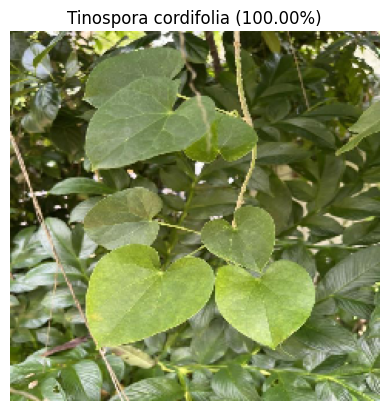

🌿 Herb: Tinospora cordifolia
📊 Confidence: 100.0 %
📖 Description: Guduchi, a powerful immunity booster. Used in fever, diabetes, and infections.

📁 Processing: 2023_06_22_10_50_IMG_5549_JPG_jpg.rf.b5d3fc111de9a3bc6e23999096be449d.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


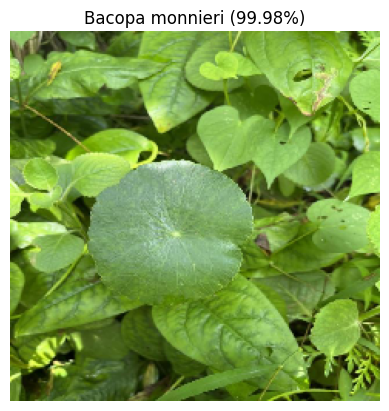

🌿 Herb: Bacopa monnieri
📊 Confidence: 99.98 %
📖 Description: A brain tonic herb used in Ayurveda. Used for memory enhancement and stress relief. It improves cognitive function and reduces anxiety.

📁 Processing: images.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


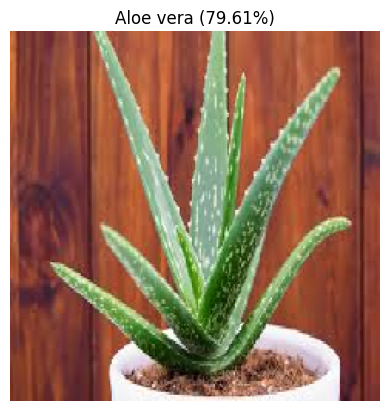

🌿 Herb: Aloe vera
📊 Confidence: 79.61 %
📖 Description: A succulent medicinal plant used in skincare and digestion. Commonly used worldwide. It helps in healing burns, improving skin health, and aiding digestion.

📁 Processing: images (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


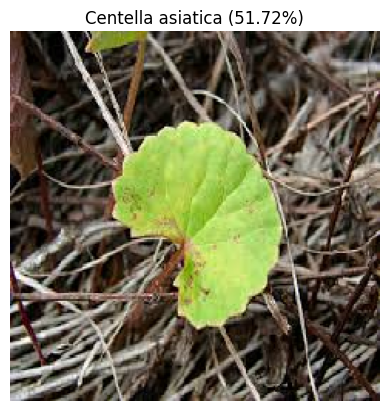

🌿 Herb: Centella asiatica
📊 Confidence: 51.72 %
📖 Description: Also called Gotu Kola. Used for brain health and wound healing. Improves memory, circulation, and skin repair.

📁 Processing: 2023_06_22_10_50_IMG_5544_JPG_jpg.rf.49eedc02325ea53938ef14bbe175ff54.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


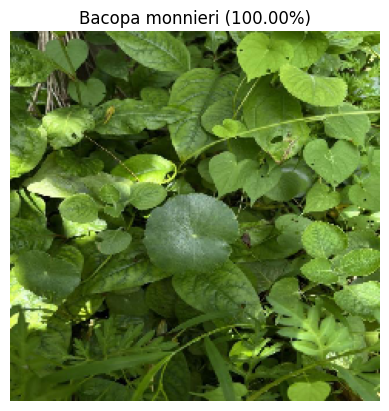

🌿 Herb: Bacopa monnieri
📊 Confidence: 100.0 %
📖 Description: A brain tonic herb used in Ayurveda. Used for memory enhancement and stress relief. It improves cognitive function and reduces anxiety.

📁 Processing: 2023_06_22_10_49_IMG_5522_JPG_jpg.rf.f01c272b4eb8bc1aa68b5587694cc4ea.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


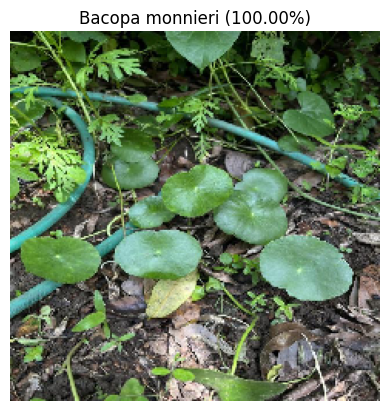

🌿 Herb: Bacopa monnieri
📊 Confidence: 100.0 %
📖 Description: A brain tonic herb used in Ayurveda. Used for memory enhancement and stress relief. It improves cognitive function and reduces anxiety.

📁 Processing: centella-asiatica-leaves.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


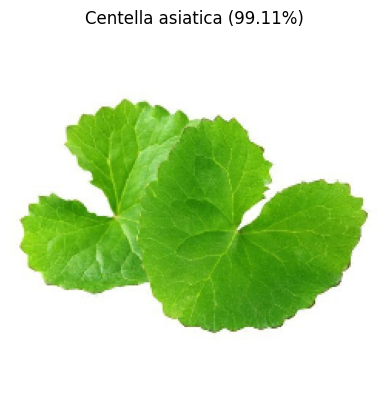

🌿 Herb: Centella asiatica
📊 Confidence: 99.11 %
📖 Description: Also called Gotu Kola. Used for brain health and wound healing. Improves memory, circulation, and skin repair.


In [86]:
for root, dirs, files in os.walk("testing_images"):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, file)
            print("\n📁 Processing:", file)
            predict_image(img_path)